## CTG Signal Analysis Guide


**This notebook is intended to help apply a tool that analyzes CTG signals, extracting features such as baseline, variability, and decelerations, to assist in the classification of CTGs as hypoxic or non-hypoxic. Following these guidelines ensures correct loading, processing, and feature extraction from CTG signals.**

For the use of this code, it is essential to adjust the paths to the directories where the CTG database to be analyzed is located.
Likewise, the database must be in the following format:

1. For each CTG, there must be a `.dat` file and a `.hea` file with the same name. This name will serve as the CTG identifier, so it is recommended, to avoid possible errors, that it be numeric.
2. The `.dat` file will contain the FHR and UC information, which must be labeled as “FHR” and “UC” respectively.
3. The `.hea` file contains clinical information about the delivery, such as:
   `["ph", "bdecf", "pco2", "be", "apgar1", "apgar5", "gest. weeks", "weight", "sex", "age", "gravidity", "parity", "diabetes", "hypertension", "preeclampsia", "liq. praecox", "pyrexia", "meconium", "presentation", "induced", "I. stage", "noProgress", "CK/KP", "II. stage", "deliv. type"]`
   The use of these category names must be preserved for proper detection.

This format was designed to maintain compatibility with the public CTU-CHB database, as it is one of the most widely used databases for the study of fetal hypoxia.
The mentioned database can be downloaded from the following link: …

Data related to the doctors’ responses to the conducted survey can be found at this link: ***. In addition, the path to the folder where these data are stored must also be adjusted.

### 1.- Import the necessary libraries

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

import sys
import os
import re

ruta_base = ".."
sys.path.append(os.path.abspath(ruta_base))

from read_data.read_data import *
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2.- Set the directory names

In [ ]:
path_folder_data = 'data/ctg_data/'
cut_time_read_data = 4 * 60 # 4 horas (Max size is 90 min = 21600 elems)
cut_time_preprocessing = 60 
method_conc = 'colors'

### 3.- Load and preprocess the data

In [10]:
data = read_data(path_folder_data, cut_time = cut_time_read_data, freq = 4)

There are 1108 files in this directory
1.- The file (RECORDS.dat) does not exist. Skipping iteration.
2.- The file (wfdbcal.dat) does not exist. Skipping iteration.
3.- The file (ANNOTATIONS.dat) does not exist. Skipping iteration.
4.- The file (SHA256SUMS.dat) does not exist. Skipping iteration.
552 ctg created!


In [11]:
data.preprocess_ctgs(rules_type = 'FIGO', cut_time = 60, rm_tail_nan=True)

### 4.- Example of CTG trace analysis

pH value of CTG 5:  7.03


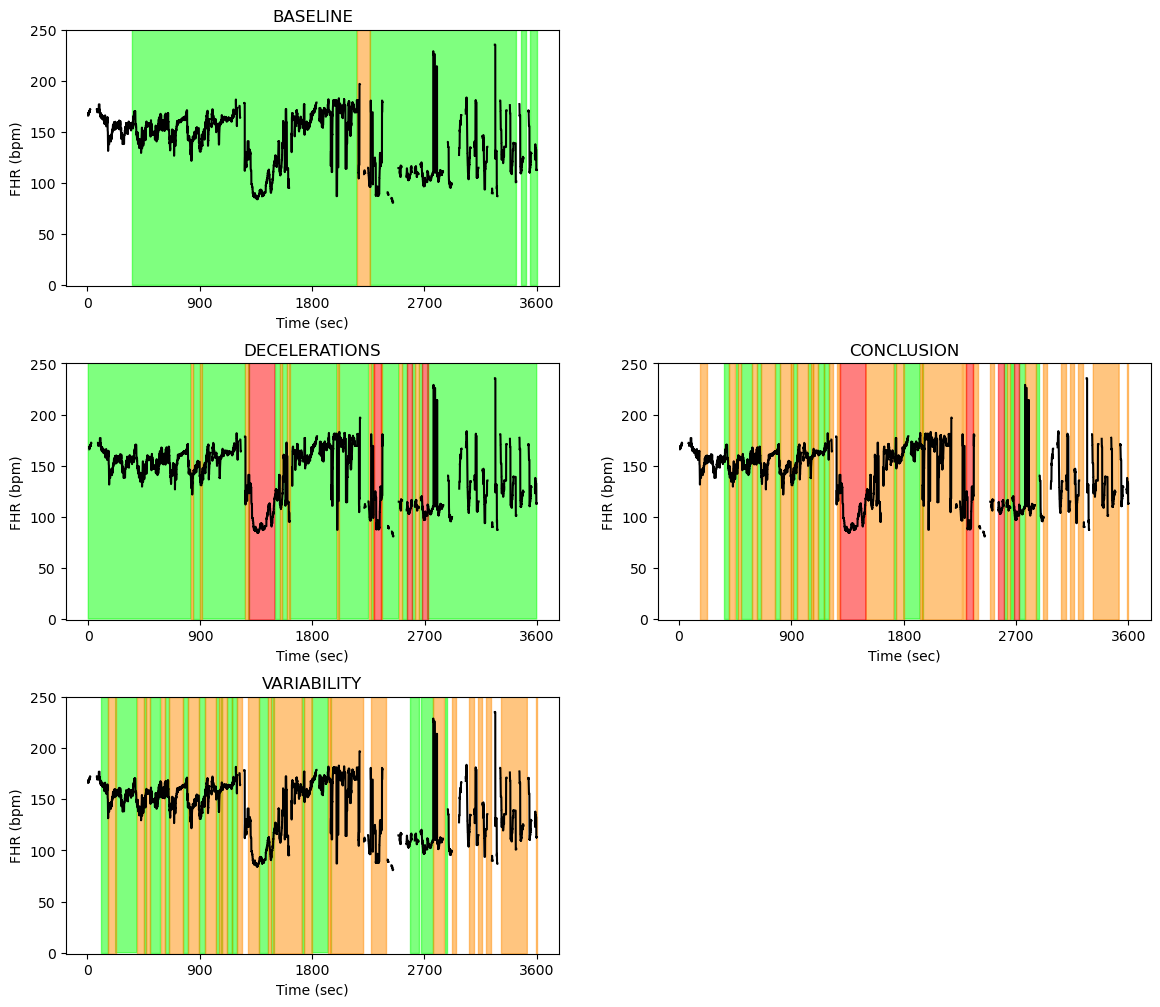

In [22]:
ctg_num_5 = data.ctgs[5]

print('pH value of CTG 5: ',ctg_num_5.ph)

conclusion_labels = ctg_num_5.apply_rules_FIGO()

### 5.- Automatic model ROC curve

The rules will be applied following the guidelines:  FIGO
552/552 

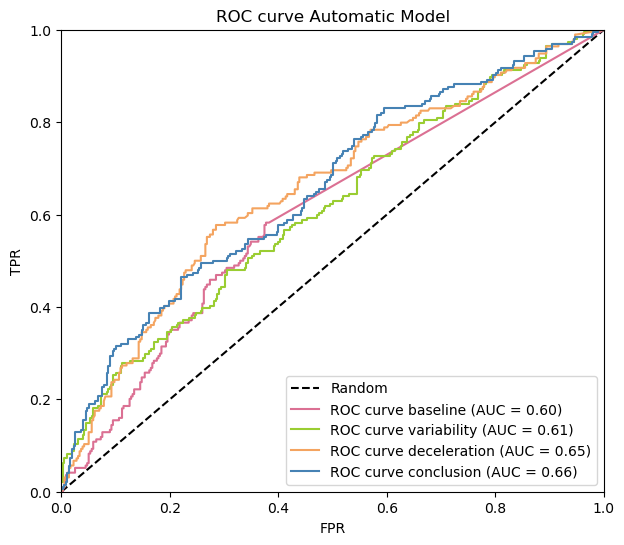

In [23]:
data.get_roc_curves(title='ROC curve Automatic Model')

### 6.- Load survey data and define ground truth

In [25]:
# Load CSV 
df = pd.read_csv("data/medical_survey/Hipoxia_Fetal2025-10-13_04_43_01.csv", encoding='utf-8')

# Filter only classification columns
classification_cols = [col for col in df.columns if "¿Cómo clasifica este RCTG?" in col]

# Create a dictionary to rename columns
new_name_cols = {}
for col in classification_cols:
    match = re.search(r'(\d+)/\d+', col) 
    if match:
        new_name_cols[col] = int(match.group(1)) 

# Apply the new names
classifications = df[classification_cols].rename(columns=new_name_cols)

# Clean and convert responses to numeric values
classifications = classifications.applymap(lambda x: str(x).strip().lower())
classifications = classifications.replace({
    'normal': 0,
    'sospechosa': 0.5,
    'patológica': 1,
    'patologica': 1
})

# Drop rows with NaN
clasificaciones_1 = classifications.iloc[:, 0:20]
classifications = clasificaciones_1.iloc[:, 0:20].loc[:, list(range(1, 21))].apply(pd.to_numeric, errors='coerce').dropna()

In [26]:
# Define the ground truth
ph = [7.33, 7.32, 7.12, 7.19, 7.2, 7.2, 7.22, 7.37, 7.0, 
      7.31, 7.13, 7.15, 7.27, 7.24, 7.3, 7.18, 6.95, 7.3, 
      7.27, 7.08]

ground_truth = [0 if valor >= 7.20 else 1 for valor in ph]

ground_truth

[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1]

In [27]:
# Create df_ctg for the survey data
survey_ids = [1309, 1340, 1161, 1288, 1283, 1412, 1473, 2041, 1017, 1150, 1400, 1249, 1450, 1113, 1378, 1154, 1359, 1366, 1332, 2043]

survey_data = DF_CTG(freq=4)
for id in survey_ids:
    ctg = data.get_ctg_by_id(id)
    survey_data.add_ctg(ctg)

### 7.- Define ROC curve: experts vs. automatic model

The rules will be applied following the guidelines:  FIGO
20/20 

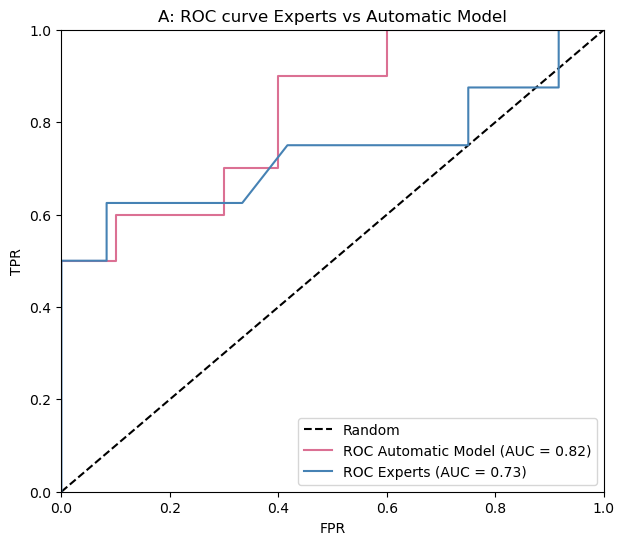

In [28]:
# Automatic model
survey_data.get_roc_curves(only_conclusion = True, title = 'A: ROC curve Experts vs Automatic Model')

# Medical model
ctg_scores = classifications.transpose().mean(axis=1).values  

fpr, tpr, thresholds = roc_curve(ground_truth, ctg_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color = 'steelblue', label=f'ROC Experts (AUC = {roc_auc:.2f})')

plt.legend(loc='lower right')

plt.savefig('roc_normal_vs_rest_medicos_aut.png', dpi=300, bbox_inches="tight")

### 8.- ROC curve for each physician

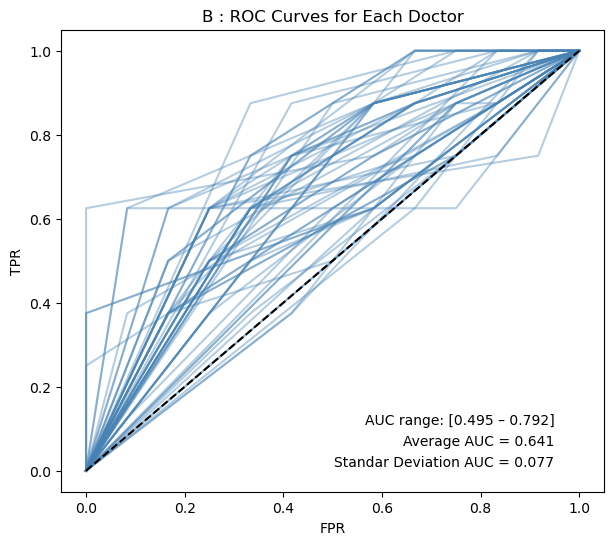

In [29]:
aucs = []
plt.figure(figsize=(7, 6))  

for i in range(len(classifications)):

    clasificaciones_medico = classifications.iloc[i]

    fpr, tpr, _ = roc_curve(ground_truth, clasificaciones_medico)
    roc_auc = auc(fpr, tpr)

    aucs.append(roc_auc)

    plt.plot(fpr, tpr, color='steelblue', alpha=0.4)

# Calculate and display average AUC
auc_promedio = np.mean(aucs)
desviacion_std = np.std(aucs)
max_auc = np.max(aucs)
min_auc = np.min(aucs)
    
plt.plot([0,1], [0,1], linestyle='--', color='black', label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title('B : ROC Curves for Each Doctor')


# Text inside the figure, bottom right
plt.text(0.95, 0.11, f"AUC range: [{min_auc:.3f} – {max_auc:.3f}]",
          fontweight='normal', ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )
plt.text(0.95, 0.06, f"Average AUC = {auc_promedio:.3f}",
          fontweight='normal', ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )
plt.text(0.95, 0.01, f"Standar Deviation AUC = {desviacion_std:.3f}",
          fontweight='normal', ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )

plt.savefig('roc_each_expert.png', dpi=300, bbox_inches="tight")
plt.show()
